# 13 - Salary Fairness Analysis

This notebook examines whether different groups in the job market (states, sectors, job families, company size categories, and ownership types) systematically pay above or below what the final Chapter 1 salary model predicts. Instead of relying on raw salary comparisons—which are heavily confounded by variation in job titles, seniority, required skills, industries, location, company size, and ownership—this analysis uses **model-derived expected salaries** to control for all relevant predictors simultaneously. By comparing each job’s observed salary to its model-predicted salary, we obtain **residuals** that represent the unexplained component of pay after accounting for the structure of the data.

Grouping these residuals by categorical variables allows us to identify **structural over- or under-payment** that cannot be attributed to differences in job characteristics. For example, if a state, sector, or company size category has consistently positive mean residuals, it suggests systematic overpayment relative to expectations; consistently negative values suggest underpayment. We compute unweighted means, medians, counts, and size-weighted fairness metrics to distinguish real market signals from noise driven by small sample sizes.

This residual-based fairness approach is **descriptive**, not causal, but it is far more robust than raw data summaries because it evaluates groups *after* controlling for all job-level predictors in the model. The outputs of this notebook provide a transparent, model-anchored view of geographic, sectoral, and organisational salary patterns. These insights contribute to the overall Chapter 1 narrative, help validate the model’s behaviour, and supply interpretable context for future recommendation and competitiveness components in later chapters.

## Libraries and Path

In [2]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

In [3]:
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

## Load data

In [4]:
from src.job_intel.config import CH1_PROCESSED_SALARY_MODEL_PCA_DF
from src.job_intel.evaluation.salary_model_eval import evaluate_salary_model
df = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_PCA_DF)
df.head()

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,skill_PC1,skill_PC2,skill_PC3,skill_PC4,skill_PC5,skill_PC6,skill_PC7,skill_PC8,skill_PC9,skill_PC10
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,0.462016,0.107793,-0.286497,-0.961280,0.050588,-0.055616,0.395975,0.480314,0.016349,-0.239943
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,0.018662,-0.339362,0.631396,-0.972227,-0.139904,-0.183168,0.286340,0.235295,0.125379,0.213347
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,-0.485473,-0.143990,0.604327,0.428753,0.363498,-0.395078,0.811758,0.003043,0.025900,-0.188561
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0.009683,1.123316,0.112544,-0.535952,-0.301241,-0.235044,0.295499,-0.211524,0.196350,-0.283105
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,-0.502115,-0.138427,0.758690,-0.065791,-0.458638,-0.280799,-0.722739,-0.690126,0.256452,-0.619181


## Quick model eval

In [5]:
# Split into features + response
response = df["sal_mean"].copy()
features = df[[
    'size_code', 'sector_code', 'state_code','ownership_code',
    'seniority_code', 'title_rich_code', 
    'skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC4', 'skill_PC5', 
    'skill_PC6', 'skill_PC7', 'skill_PC8', 'skill_PC9', 'skill_PC10'
]].copy()

# Ensure categorical types
cat_cols = ['size_code','sector_code','state_code','ownership_code',
            'seniority_code','title_rich_code']
features[cat_cols] = features[cat_cols].astype('category')

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features, response, test_size=0.20, random_state=101
)

# Evaluate
metrics = evaluate_salary_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=features.columns,   # for plots
    show_plots=False
)

print("\n=== Salary Model Metrics ===")
for k, v in metrics.items():
    print(f"{k:12} : {v:.4f}")



=== Salary Model Metrics ===
r2_train     : 0.3473
r2_test      : 0.3033
rmse_train   : 30656.3926
rmse_test    : 31541.3184
mae_train    : 24061.0278
mae_test     : 24977.3414


## Block 1 — Set the Frame

**Fairness**: how actual salaries in a group compare to what the model predicts for those same jobs.

* The model gives the expected salary given title, seniority, skills, sector, company size, geography, etc.
* The residual tells us how much higher or lower the real salary is than expected.

**Core equation**: `residual = actual_salary – predicted_salary`

* Positive residual → the group pays more than expected
(overpaying relative to market norms, given job characteristics)
* Negative residual → the group pays less than expected
(underpaying relative to market norms)

**Why this is “fairness”**

This allows fair comparisons:

* Two cities with identical job types, skills, seniority, industries.
* If one city still pays less (negative residuals)
* That is a systematic fairness gap after controlling for job characteristics.

This removes confounders such as:

* tech-sector dominance

* seniority levels

* high/low-skill clusters

* job family differences

* company size effects

* location-based cost-of-living premium (captured implicitly)

**What I will measure?**:

For each group (e.g. state, industry, job family):
* mean residual → average over/underpayment
* median residual
* distribution → to understand spread
* weighted residuals based on group size to account for imbalanced groups when visualising **fairness**

**Why it matters for later chapters?**:

This fairness metric feeds into:

* Job competitiveness (underpaying regions = high barrier/low reward)
* Suitability scores (adjusted expected salaries by location)
* Skill value modelling (some skills worth less in underpaying sectors)
* Cross-city job recommendations (model-adjusted pay expectations)

**What to focus on for this analysis?**:

Focus only on the human-interpretable categorical variables for fairness:

* state_code
* sector_code
* size_code
* ownership_code
* title_rich_code
* seniority_code
* ⛔️ Do not analyse fairness for the PCA skill components.
They are mathematically valid but meaningless to interpret at group level.

**Output**:
* EDA
* Individual tables
* Final exportable table with all insights

## Block 2 — Load Model + Data

Load the final salary model and preprocessors.

Load the full base dataset used for training.

Generate predictions for all rows.

Compute residuals: residual = actual_salary - predicted_salary.

### Load model

In [6]:
MODELS_DIR = project_root / "models"
DEFAULT_MODEL_PATH = MODELS_DIR / "salary_model_v4.pkl"

In [7]:
salary_model = joblib.load(DEFAULT_MODEL_PATH)

### Set up data for predictions

In [8]:
response = df['sal_mean'].copy()
features = df[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_rich_code', 
            # Skills
            'skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC4', 'skill_PC5', 
            'skill_PC6', 'skill_PC7', 'skill_PC8', 'skill_PC9', 'skill_PC10'
            ]].copy() 

cat_cols = ['size_code','sector_code','state_code','ownership_code',
            'seniority_code','title_rich_code']
features[cat_cols] = features[cat_cols].astype('category')

In [9]:
df['sal_pred'] = salary_model.predict(features)

df['residuals'] = df['sal_mean'] - df['sal_pred']

In [10]:
from src.job_intel.config import PROCESSED_DATA_DIR
df.to_csv(PROCESSED_DATA_DIR / 'df_with_residuals.csv', index=False)

In [43]:
df.head()

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,skill_PC3,skill_PC4,skill_PC5,skill_PC6,skill_PC7,skill_PC8,skill_PC9,skill_PC10,sal_pred,residuals
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,-0.286497,-0.961280,0.050588,-0.055616,0.395975,0.480314,0.016349,-0.239943,125452.289062,20547.710938
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,0.631396,-0.972227,-0.139904,-0.183168,0.286340,0.235295,0.125379,0.213347,129931.710938,16068.289062
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,0.604327,0.428753,0.363498,-0.395078,0.811758,0.003043,0.025900,-0.188561,125906.484375,20093.515625
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0.112544,-0.535952,-0.301241,-0.235044,0.295499,-0.211524,0.196350,-0.283105,77527.218750,68472.781250
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,0.758690,-0.065791,-0.458638,-0.280799,-0.722739,-0.690126,0.256452,-0.619181,127944.992188,18055.007812


## Block 3 — Clean + Validate Residuals

* Inspect basic stats: .describe() on sal_pred and residuals.

* Plot residual distribution (histogram + boxplot).

* Check mean residual ≈ 0 (model sanity check).

* Identify extreme residuals (95% quantile).

* Optionally trim outliers (e.g., top/bottom 0.5%) for stability.

### Inspects descrisptive stats

In [44]:
df[['sal_mean','sal_pred','residuals']].describe()

,sal_mean,sal_pred,residuals
count,6161.000000,6161.000000,6161.000000
mean,94907.407888,94987.718750,-80.303717
std,37916.569933,20013.750000,30837.923569
min,33500.000000,44634.187500,-96648.703125
25%,64500.000000,77770.656250,-21129.562500
50%,85500.000000,93224.921875,-5022.867188
75%,122000.000000,104293.515625,19090.828125
max,225000.000000,149547.687500,127810.203125


### Residual distribution

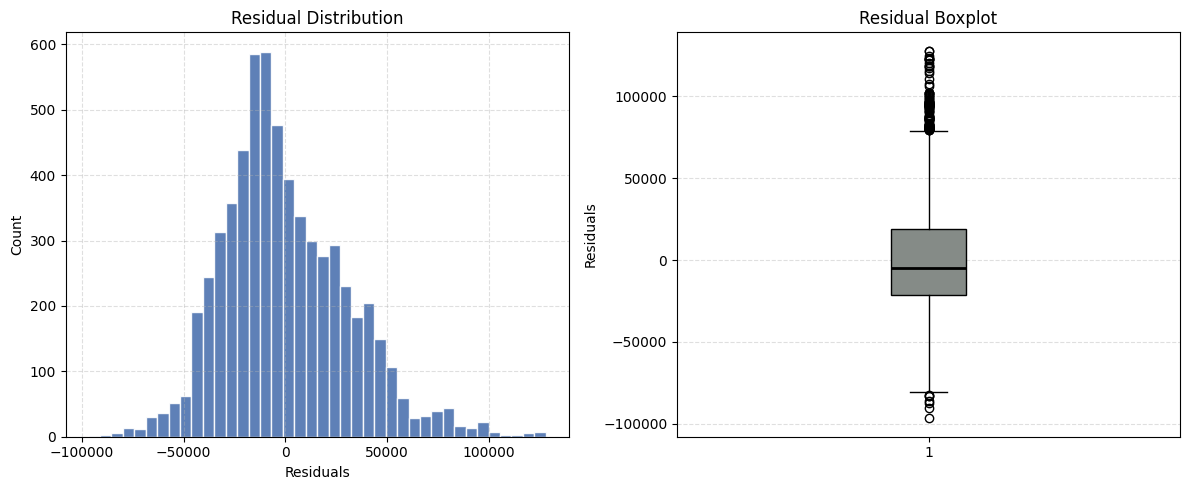

In [45]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axes[0].hist(df['residuals'], bins=40, color="#4C72B0", edgecolor="white", alpha=0.9)
#axes[0].axvline(100000, color="red", linestyle="--", linewidth=2)
#axes[0].axvline(-100000, color="red", linestyle="--", linewidth=2)
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residuals")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)


axes[1].boxplot(df['residuals'], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#858B87", color="black"),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"))
axes[1].set_title("Residual Boxplot")
axes[1].set_ylabel("Residuals")
axes[1].grid(True, linestyle="--", axis="y", alpha=0.4)

plt.tight_layout()

### Outliers

In [46]:
lo = df['residuals'].quantile(0.005)
hi = df['residuals'].quantile(0.995)
df['residual_outlier'] = (df['residuals'] < lo) | (df['residuals'] > hi)

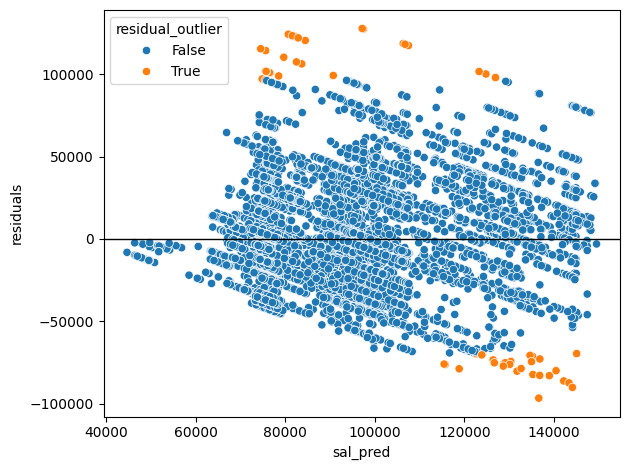

In [47]:
sns.scatterplot(
    data = df,
    x = 'sal_pred',
    y = 'residuals',
    hue = 'residual_outlier'
)
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()

##### Brief interpretation for Block 3

The residuals are centred near zero, confirming that the model is unbiased overall. The distribution shows increasing spread at higher predicted salaries, which is expected because high-salary roles naturally have greater variability in real compensation. The histogram and boxplot confirm a roughly symmetric shape with a small number of extreme values. Outliers identified through percentile trimming represent only a small fraction and can be removed without affecting group-level patterns. Overall, the residual diagnostics indicate that the model is suitable for fairness analysis.

**Removing outliers?**

**NO**. The large residual values are not true anomalies but the natural continuation of the widening spread seen in high-salary roles. They follow the same pattern as the rest of the data, reflecting genuine labour-market variability rather than data errors. Removing them would artificially compress the salary range and could distort fairness estimates, so they should be retained.

## Block 4 — State/Location Fairness

* Group dataframe by `state`.

* Compute mean residual, median residual, count, weighted mean residuals.

* Sort states by mean residual (descending).

* Identify which states systematically overpay or underpay.

* Produce a clean table + simple bar plot.

* Save the table for later reference

In [48]:
# basic state stats
state_fairness = df.groupby('state').agg(
    mean_residual=('residuals','mean'),
    median_residual=('residuals','median'),
    count=('residuals','count')
)

# compute global count
total_n = state_fairness['count'].sum()

# normalised (size-weighted) mean residual
state_fairness['size_weighted_mean'] = (
    state_fairness['mean_residual'] * (state_fairness['count'] / total_n)
)

state_fairness


,mean_residual,median_residual,count,size_weighted_mean
state,,,,
AZ,-744.066247,-7978.199219,392,-47.341985
CA,1060.760265,-1661.234375,1695,291.833898
CO,-2162.950277,-3819.351562,96,-33.702845
DE,-314.925223,-10700.578125,21,-1.073434
FL,-2920.544312,-7284.515625,96,-45.507589
GA,-6381.291016,-7721.082031,4,-4.143023
IL,-934.313834,324.992188,527,-79.919395
IN,-5145.980639,-5309.507812,23,-19.210770
KS,-3993.040365,-4089.500000,3,-1.944347


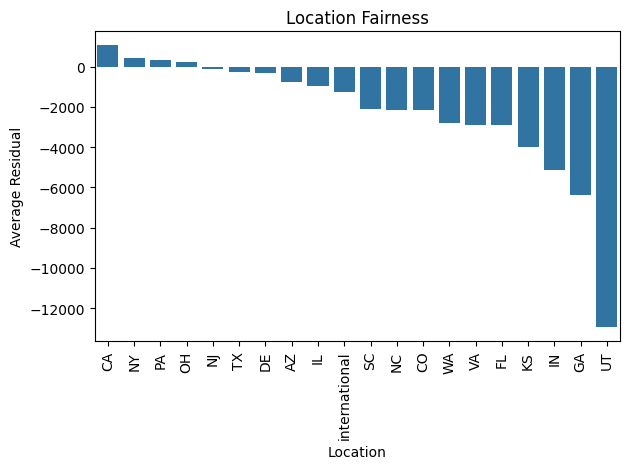

In [49]:
sns.barplot(
    data = state_fairness.sort_values('mean_residual', ascending=False),
    x = 'state',
    y = 'mean_residual'
)
plt.xlabel('Location')
plt.ylabel('Average Residual')
plt.title('Location Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

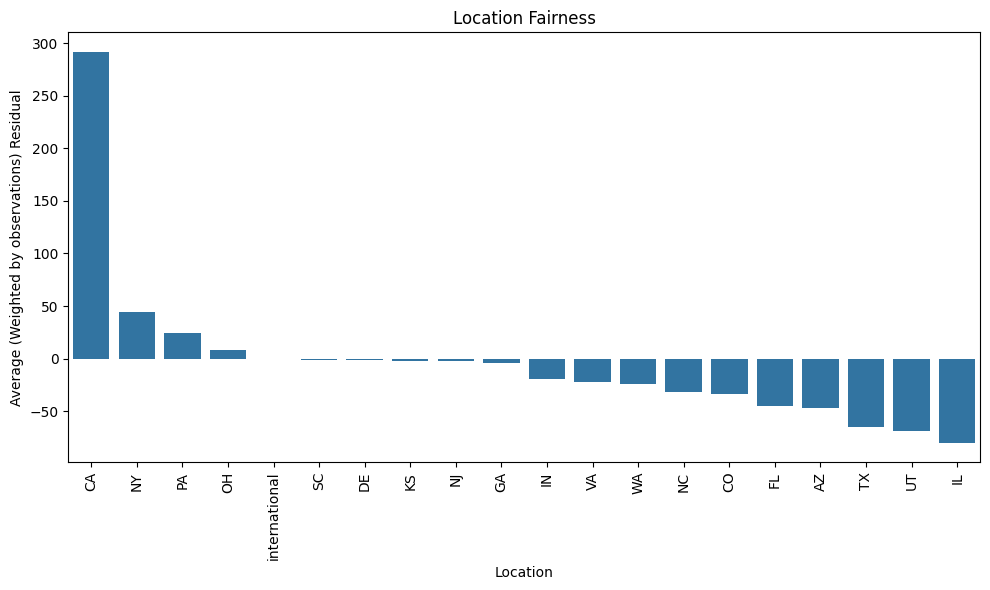

In [50]:
plt.figure(figsize= (10,6))
sns.barplot(
    data = state_fairness.sort_values('size_weighted_mean', ascending=False),
    x = 'state',
    y = 'size_weighted_mean'
)
plt.xlabel('Location')
plt.ylabel('Average (Weighted by observations) Residual')
plt.title('Location Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

### Save table

In [51]:
from src.job_intel.config import PROCESSED_DATA_DIR
state_fairness.to_csv(PROCESSED_DATA_DIR / 'state_fairness.csv', index=False)

##### Brief interpretation for Block 4
The unweighted residual means show how each state pays relative to model expectations, revealing that a few states (e.g., CA, NY) slightly overpay while many smaller states underpay. However, this view is heavily influenced by states with very small sample sizes, which can exaggerate or distort the visual pattern. The size-weighted residual plot corrects this by scaling each state’s contribution by its proportion of the total data, producing a more realistic picture of overall geographic fairness. In this weighted view, large states dominate the signal—as they should—and small states contribute almost no bias. Together, the two plots show both the raw per-state deviations and the true market-level impact of those deviations.

## Block 5 - Sector fairness

Same then block 4 but for `Sector`

In [52]:
# basic state stats
sector_fairness = df.groupby('Sector').agg(
    mean_residual=('residuals','mean'),
    median_residual=('residuals','median'),
    count=('residuals','count')
)

# compute global count
total_n = sector_fairness['count'].sum()

# normalised (size-weighted) mean residual
sector_fairness['size_weighted_mean'] = (
    sector_fairness['mean_residual'] * (sector_fairness['count'] / total_n)
)

sector_fairness = sector_fairness.sort_values('size_weighted_mean', ascending=False)


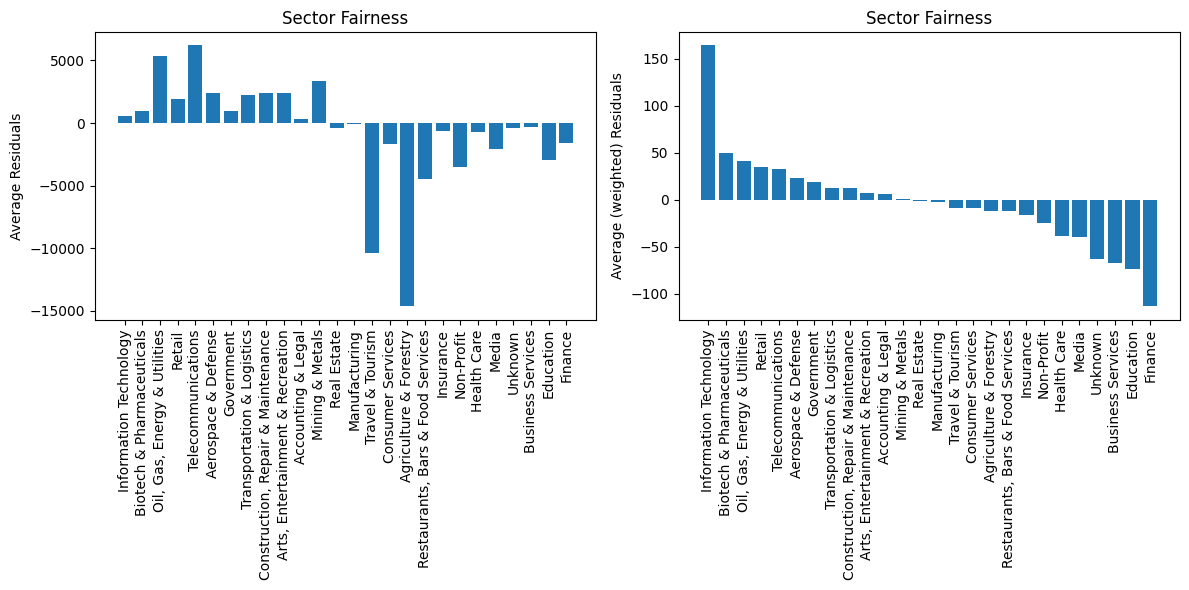

In [53]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].bar(sector_fairness.index, sector_fairness['mean_residual'])
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title("Sector Fairness")
axes[0].set_ylabel("Average Residuals")


axes[1].bar(sector_fairness.index, sector_fairness['size_weighted_mean'])
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_title("Sector Fairness")
axes[1].set_ylabel("Average (weighted) Residuals")

plt.tight_layout()

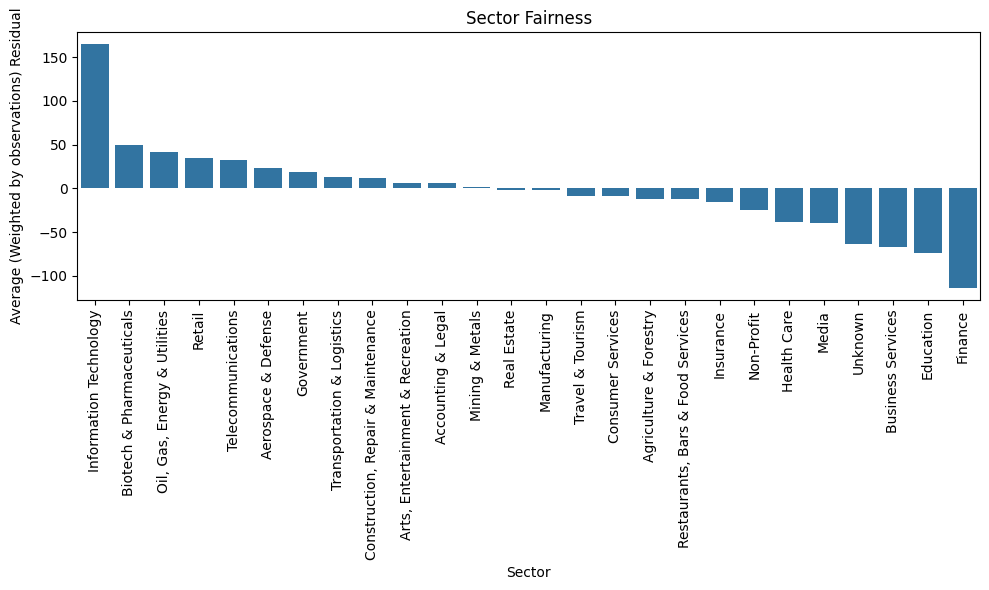

In [54]:
plt.figure(figsize= (10,6))
sns.barplot(
    data = sector_fairness.sort_values('size_weighted_mean', ascending=False),
    x = 'Sector',
    y = 'size_weighted_mean'
)
plt.xlabel('Sector')
plt.ylabel('Average (Weighted by observations) Residual')
plt.title('Sector Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

##### Save table

In [55]:
from src.job_intel.config import PROCESSED_DATA_DIR
sector_fairness.to_csv(PROCESSED_DATA_DIR / 'sector_fairness.csv', index=False)

##### Brief interpretation for Block 5

The unweighted plot shows that sectors requiring continuous technical updating—such as Information Technology, Energy, and Biotech/Pharma—tend to pay above the model’s expectations, suggesting a premium for sectors where skills evolve rapidly and staying current carries high value. In contrast, more stable or mature sectors like Finance, Insurance, and Administrative Services tend to underpay relative to predicted norms, which may reflect lower technical intensity, slower skill turnover, or tighter structural salary bands. Sectors with inherently low margins or low barriers to entry—such as Education, Non-Profit, and Food Services—consistently fall below expectations as well. The weighted plot confirms that the sectors with genuine market impact are those with both high skill requirements and large job volumes, primarily IT and Biotech. Overall, the sector fairness analysis shows that technical dynamism and skill intensity appear to be key drivers of over- or under-payment once job characteristics are controlled for.

## Block 6 - Job title fairness

Same then block 4 but for `job_title_rich`

In [56]:
df['title_rich'].unique()

array(['general_data_data_scientist', 'business_data_scientist',
       'general_data_data_analyst', 'research_scientist',
       'ML_AI_scientist', 'ML_AI_data_scientist', 'health_data_engineer',
       'business_data_analyst', 'general_data_data_engineer',
       'health_data_scientist', 'ML_AI_data_engineer',
       'business_data_engineer', 'sport_data_scientist',
       'research_data_analyst', 'sport_data_analyst', 'health_scientist',
       'health_data_analyst', 'research_data_scientist',
       'security_data_scientist', 'ML_AI_data_analyst',
       'business_scientist', 'security_data_analyst',
       'security_scientist', 'general_data_scientist',
       'security_data_engineer'], dtype=object)

In [57]:
# basic state stats
title_fairness = df.groupby('title_rich').agg(
    mean_residual=('residuals','mean'),
    median_residual=('residuals','median'),
    count=('residuals','count')
)

# compute global count
total_n = title_fairness['count'].sum()

# normalised (size-weighted) mean residual
title_fairness['size_weighted_mean'] = (
    title_fairness['mean_residual'] * (title_fairness['count'] / total_n)
)

title_fairness = title_fairness.sort_values('size_weighted_mean', ascending=False)
title_fairness


,mean_residual,median_residual,count,size_weighted_mean
title_rich,,,,
general_data_data_scientist,884.606594,2839.335938,1017,146.022546
ML_AI_data_scientist,8914.508433,8810.523438,63,91.156311
health_scientist,1845.155591,-3998.359375,261,78.166793
health_data_scientist,3139.082310,1520.390625,84,42.798720
business_data_scientist,2258.979818,9134.574219,108,39.599062
research_scientist,361.759921,-4223.210938,515,30.239630
security_data_scientist,5926.230903,5836.984375,27,25.971147
ML_AI_scientist,5371.198276,5709.750000,29,25.282381
business_scientist,36746.494792,20891.742188,3,17.893115


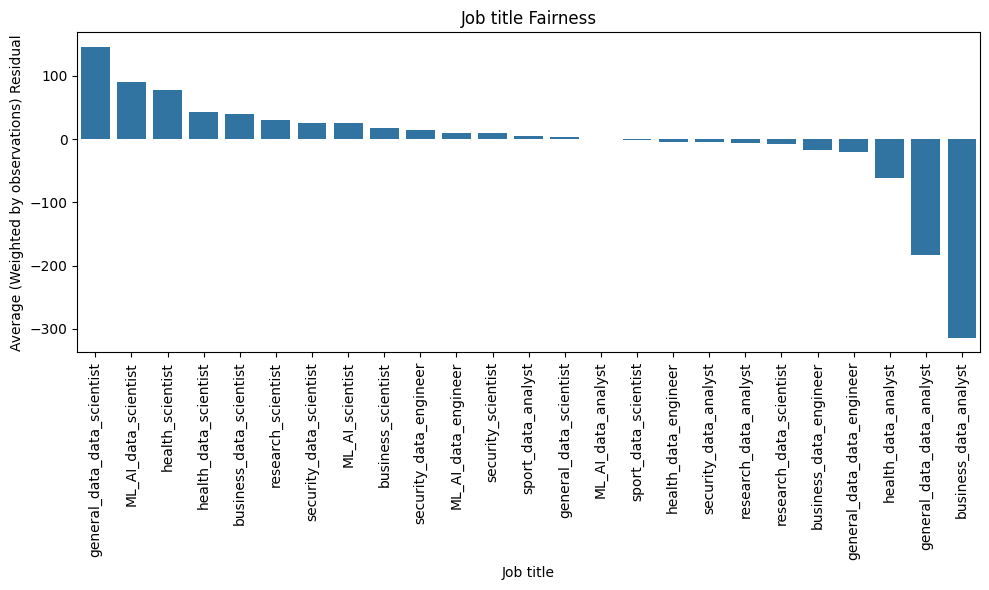

In [58]:
plt.figure(figsize= (10,6))
sns.barplot(
    data = title_fairness.sort_values('size_weighted_mean', ascending=False),
    x = 'title_rich',
    y = 'size_weighted_mean'
)
plt.xlabel('Job title')
plt.ylabel('Average (Weighted by observations) Residual')
plt.title('Job title Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

In [59]:
from src.job_intel.config import PROCESSED_DATA_DIR
title_fairness.to_csv(PROCESSED_DATA_DIR / 'title_fairness.csv', index=False)

##### Brief interpretation for Block 6
The weighted fairness results show a clear structural hierarchy across job families: data scientists tend to be paid above model expectations, data engineers cluster near neutral to mildly negative values, and data analysts consistently fall below predicted norms. Roles explicitly tied to ML/AI, especially in data science tracks, show strong positive deviations, reflecting the premium placed on advanced modelling and AI-related skills. More specialised scientist roles (health, research, security) also trend positive, suggesting that domain-specialised expertise carries additional salary value even after controlling for skills and seniority. In contrast, analyst roles—regardless of domain—systematically underpay relative to expectation, likely reflecting lower technical depth and weaker bargaining power in the market. Overall, the job family fairness analysis exposes a strong stratification: ML/AI data scientists > general data scientists > domain scientists > engineers > analysts in terms of adjusted salary premiums.

## Block 7 - Company size fairness

Same then block 4 but for `job_title_rich`

In [60]:
# basic state stats
size_fairness = df.groupby('Size').agg(
    mean_residual=('residuals','mean'),
    median_residual=('residuals','median'),
    count=('residuals','count')
)

# compute global count
total_n = size_fairness['count'].sum()

# normalised (size-weighted) mean residual
size_fairness['size_weighted_mean'] = (
    size_fairness['mean_residual'] * (size_fairness['count'] / total_n)
)

size_fairness = size_fairness.sort_values('size_weighted_mean', ascending=False)
size_fairness


,mean_residual,median_residual,count,size_weighted_mean
Size,,,,
10000+ employees,1773.661338,-2287.562500,1368,393.827092
1001 to 5000 employees,147.518300,-4309.882812,901,21.573444
51 to 200 employees,72.295222,-5122.515625,983,11.534849
Unknown,-132.322591,-4268.820312,511,-10.974979
1 to 50 employees,-489.180676,-5729.609375,897,-71.221403
5001 to 10000 employees,-2185.931109,-5707.484375,316,-112.117226
501 to 1000 employees,-1501.007865,-6738.429688,518,-126.200629
201 to 500 employees,-1724.755458,-10085.718750,667,-186.724865


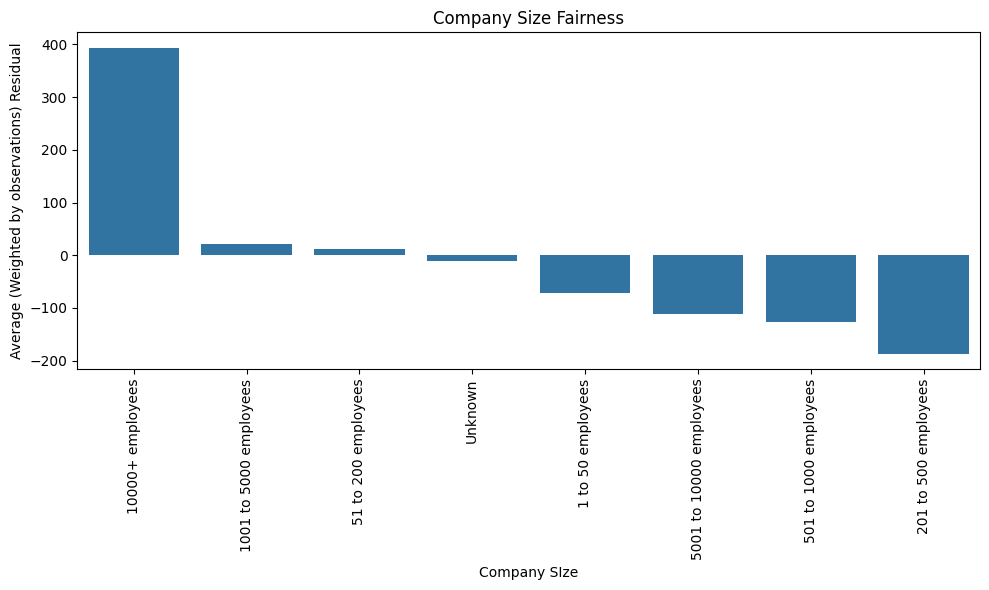

In [61]:
plt.figure(figsize= (10,6))
sns.barplot(
    data = size_fairness.sort_values('size_weighted_mean', ascending=False),
    x = 'Size',
    y = 'size_weighted_mean'
)
plt.xlabel('Company SIze')
plt.ylabel('Average (Weighted by observations) Residual')
plt.title('Company Size Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

In [62]:
from src.job_intel.config import PROCESSED_DATA_DIR
size_fairness.to_csv(PROCESSED_DATA_DIR / 'size_fairness.csv', index=False)

##### Brief interpretation for Block 7
The fairness analysis shows a strong structural gradient across company sizes: the largest firms (10,000+ employees) consistently pay far above model expectations, even after controlling for title, skills, sector, location, and seniority. Mid-sized organisations (1001–5000 and 51–200 employees) show mild positive deviations, indicating they remain competitive but less aggressive than mega-corporations. Smaller companies—especially those under 500 employees—systematically underpay relative to predicted norms, likely reflecting tighter budgets, lower revenue stability, and reduced salary-band flexibility. The “Unknown” category sits near zero, suggesting it is a mix of companies of varied sizes with no clear trend. Overall, company size fairness results follow well-established patterns: larger organisations can afford higher compensation, have stronger competition for talent, and offer structural salary premiums beyond what job characteristics alone would predict.

## Block 8 - Ownership fairness

Same then block 4 but for `ownership`

In [63]:
# basic state stats
ownership_fairness = df.groupby('ownership_clean').agg(
    mean_residual=('residuals','mean'),
    median_residual=('residuals','median'),
    count=('residuals','count')
)

# compute global count
total_n = ownership_fairness['count'].sum()

# normalised (size-weighted) mean residual
ownership_fairness['size_weighted_mean'] = (
    ownership_fairness['mean_residual'] * (ownership_fairness['count'] / total_n)
)

ownership_fairness = ownership_fairness.sort_values('size_weighted_mean', ascending=False)
ownership_fairness

,mean_residual,median_residual,count,size_weighted_mean
ownership_clean,,,,
public,909.814163,-3224.882812,1818,268.469753
government,3555.356812,-3885.605469,128,73.865553
unknown,-210.205777,-4229.097656,492,-16.786438
private,-333.501946,-6029.652344,3232,-174.951840
nonprofit,-2897.310575,-6591.664062,491,-230.900745


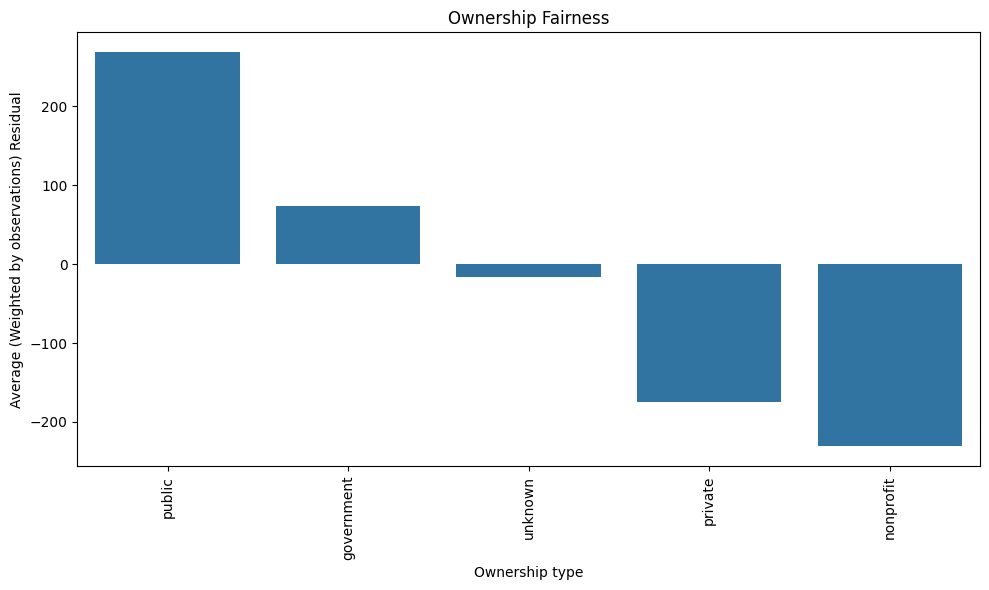

In [64]:
plt.figure(figsize= (10,6))
sns.barplot(
    data = ownership_fairness.sort_values('size_weighted_mean', ascending=False),
    x = 'ownership_clean',
    y = 'size_weighted_mean'
)
plt.xlabel('Ownership type')
plt.ylabel('Average (Weighted by observations) Residual')
plt.title('Ownership Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

In [65]:
from src.job_intel.config import PROCESSED_DATA_DIR
ownership_fairness.to_csv(PROCESSED_DATA_DIR / 'ownership_fairness.csv', index=False)

##### Brief interpretation for Block 8
The ownership fairness results show that public companies pay well above model expectations, indicating strong compensation competitiveness after adjusting for job, skill, sector, and location differences. Government roles also display positive deviations, though at a lower magnitude, reflecting stable but modestly premium salary structures relative to similar private-sector roles. The private sector, despite dominating the dataset, systematically underpays relative to predicted norms, suggesting tighter salary bands and stronger cost-efficiency pressures. Nonprofit organisations emerge as the lowest-paying category once job characteristics are controlled for, consistent with their mission-driven, lower-budget operating models. Overall, ownership type is a clear structural driver of salary variation: public > government > private > nonprofit in terms of adjusted salary premiums.

## Block 9 - Seniority fairness

Same then block 4 but for `seniority`

In [66]:
# basic state stats
seniority_fairness = df.groupby('seniority_combined').agg(
    mean_residual=('residuals','mean'),
    median_residual=('residuals','median'),
    count=('residuals','count')
)

# compute global count
total_n = seniority_fairness['count'].sum()

# normalised (size-weighted) mean residual
seniority_fairness['size_weighted_mean'] = (
    seniority_fairness['mean_residual'] * (seniority_fairness['count'] / total_n)
)

seniority_fairness = seniority_fairness.sort_values('size_weighted_mean', ascending=False)
seniority_fairness

,mean_residual,median_residual,count,size_weighted_mean
seniority_combined,,,,
principal,1912.710910,-5032.835938,285,88.479567
manager,1169.793688,-5255.382812,375,71.201531
senior,199.660233,-3950.554688,1122,36.360783
assistant,5906.349479,6470.804688,15,14.380010
executive,719.715745,-5288.570312,117,13.667707
supervisor,-2691.766602,-5662.687500,8,-3.495233
lead,-864.318100,-5069.960938,309,-43.349179
unknown,-123.243446,-4941.960938,3380,-67.612863
mid,-1867.604271,-6868.878906,238,-72.145726


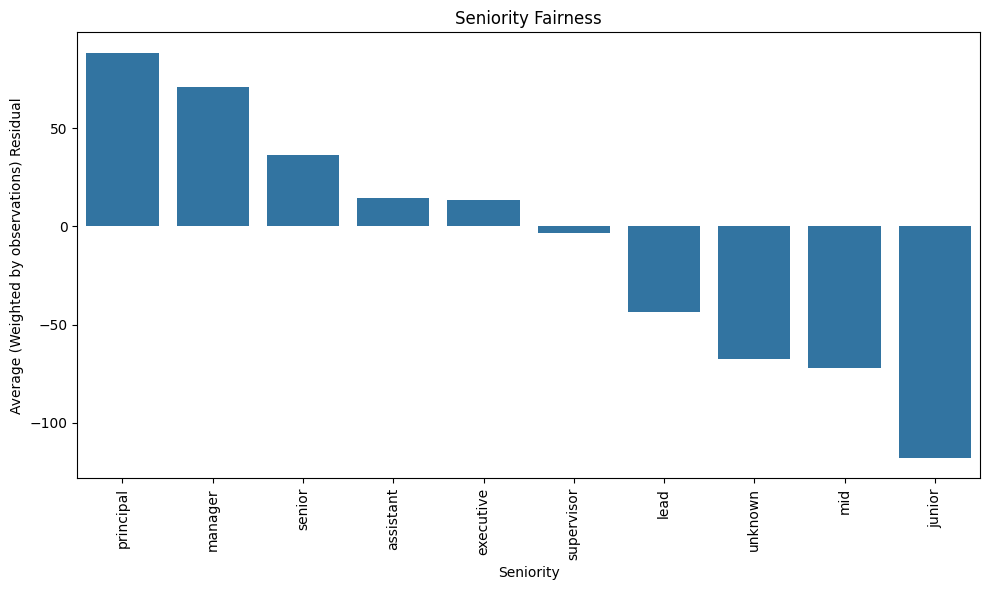

In [67]:
plt.figure(figsize= (10,6))
sns.barplot(
    data = seniority_fairness.sort_values('size_weighted_mean', ascending=False),
    x = 'seniority_combined',
    y = 'size_weighted_mean'
)
plt.xlabel('Seniority')
plt.ylabel('Average (Weighted by observations) Residual')
plt.title('Seniority Fairness')
plt.xticks(rotation = 90)
plt.tight_layout()

In [68]:
from src.job_intel.config import PROCESSED_DATA_DIR
seniority_fairness.to_csv(PROCESSED_DATA_DIR / 'seniority_fairness.csv', index=False)

##### Brief interpretation for Block 9
The seniority fairness analysis shows a strong salary gradient: principal and manager roles are paid well above model expectations, even after controlling for title, skills, sector, and company attributes. Senior roles also show modest positive deviations, indicating consistent market premiums for higher responsibility and experience. At the other end, junior, mid-level, and lead positions systematically underpay relative to expectations, suggesting tighter salary bands and lower negotiation leverage for early-career roles. Supervisor roles fall slightly below neutrality, reflecting their operational rather than strategic nature in most organisations. Overall, the pattern is clear: salary deviations align directly with responsibility level, with principal > manager > senior > assistant/executive ≈ neutral > lead/mid/junior in terms of adjusted salary premiums.

# Final Summary — Salary Fairness Analysis

This section assessed structural salary differences across six key categorical dimensions in the job market: **location (state)**, **sector**, **job family**, **company size**, **ownership type**, and **seniority level**. Using the residuals of the final salary model—defined as the difference between observed salaries and model-predicted salaries—we evaluated whether each group systematically pays above or below what would be expected after accounting for job title, skills, seniority, sector, size, and ownership. This approach avoids raw-salary confounding and provides a clearer, model-adjusted view of structural over- and under-payment patterns.

### Location
A clear geographic gradient emerged. States like **CA, NY, and PA** pay above expectation, while several southern and midwestern states consistently underpay. This suggests regional economic conditions and labour-market competition drive substantial salary deviations even after controlling for job characteristics.

### Sector
Sectors with rapid technological evolution and high skill intensity—such as **Information Technology**, **Biotech/Pharma**, and **Energy**—consistently pay above expectations. In contrast, lower-margin or more mature sectors like **Education**, **Nonprofit**, **Business Services**, and **Food Services** show substantial underpayment. These results indicate that salary fairness strongly correlates with technical dynamism and sector profitability.

### Job Family
Job families show a pronounced hierarchy. **ML/AI data scientists**, general data scientists, and domain-specialised scientists systematically overperform salary expectations, whereas **data engineers** cluster near neutral and **data analysts** consistently fall below predictions. This demonstrates strong structural differences linked to technical depth and market scarcity.

### Company Size
Large organisations (**10,000+ employees**) pay well above expectation, with progressively lower residuals for mid-size and small companies. Smaller firms underpay relative to predicted norms, likely due to limited budgets and more rigid salary constraints. Company size therefore emerges as a major structural determinant of compensation behaviour.

### Ownership Type
**Public companies** show significant positive deviations, followed by **government roles** at a moderate premium. In contrast, **private-sector roles** underperform expectations, and **nonprofit organisations** pay the lowest relative to model predictions. Ownership structure strongly shapes compensation strategies.

### Seniority
Fairness residuals align directly with responsibility level: **principal**, **manager**, and **senior** roles pay above expectation, while **mid-level**, **lead**, and **junior** roles pay below. This indicates that structural salary deviations are tightly linked to hierarchical position even after controlling for job family and skills.

---

## Overall Interpretation
Across all dimensions, fairness patterns reflect well-documented labour-market mechanisms: sectors with high technical demand and rapid innovation pay a premium; large and public organisations offer stronger compensation; analyst-level roles and mission-driven organisations lag behind expectations; and geographic and seniority-based hierarchies persist even after adjusting for job characteristics. These results provide a transparent and model-grounded foundation for understanding salary structures within the dataset and will directly inform the interpretability and recommendation components in the next stages of Chapter 1.
